# Figure 2: Jiang24 seen perturbation benchmark

Reproduces the main Jiang24 seen-perturbation benchmark panels and example perturbation profile. Run after generating `results/collected/jiang/seen_pred_results.pkl`.


In [1]:
# Set to True to write image files to figures/main/output/.
SAVE_FIGURES = False

## Benchmark summary


Median MSE on DEGs:
TranScouter    0.116865
Avg            0.550046
scGen          0.163403
trVAE          0.138242
dtype: float64

Median DMR on DEGs:
TranScouter    0.157895
Avg            0.400000
scGen          0.240000
trVAE          0.160000
dtype: float64


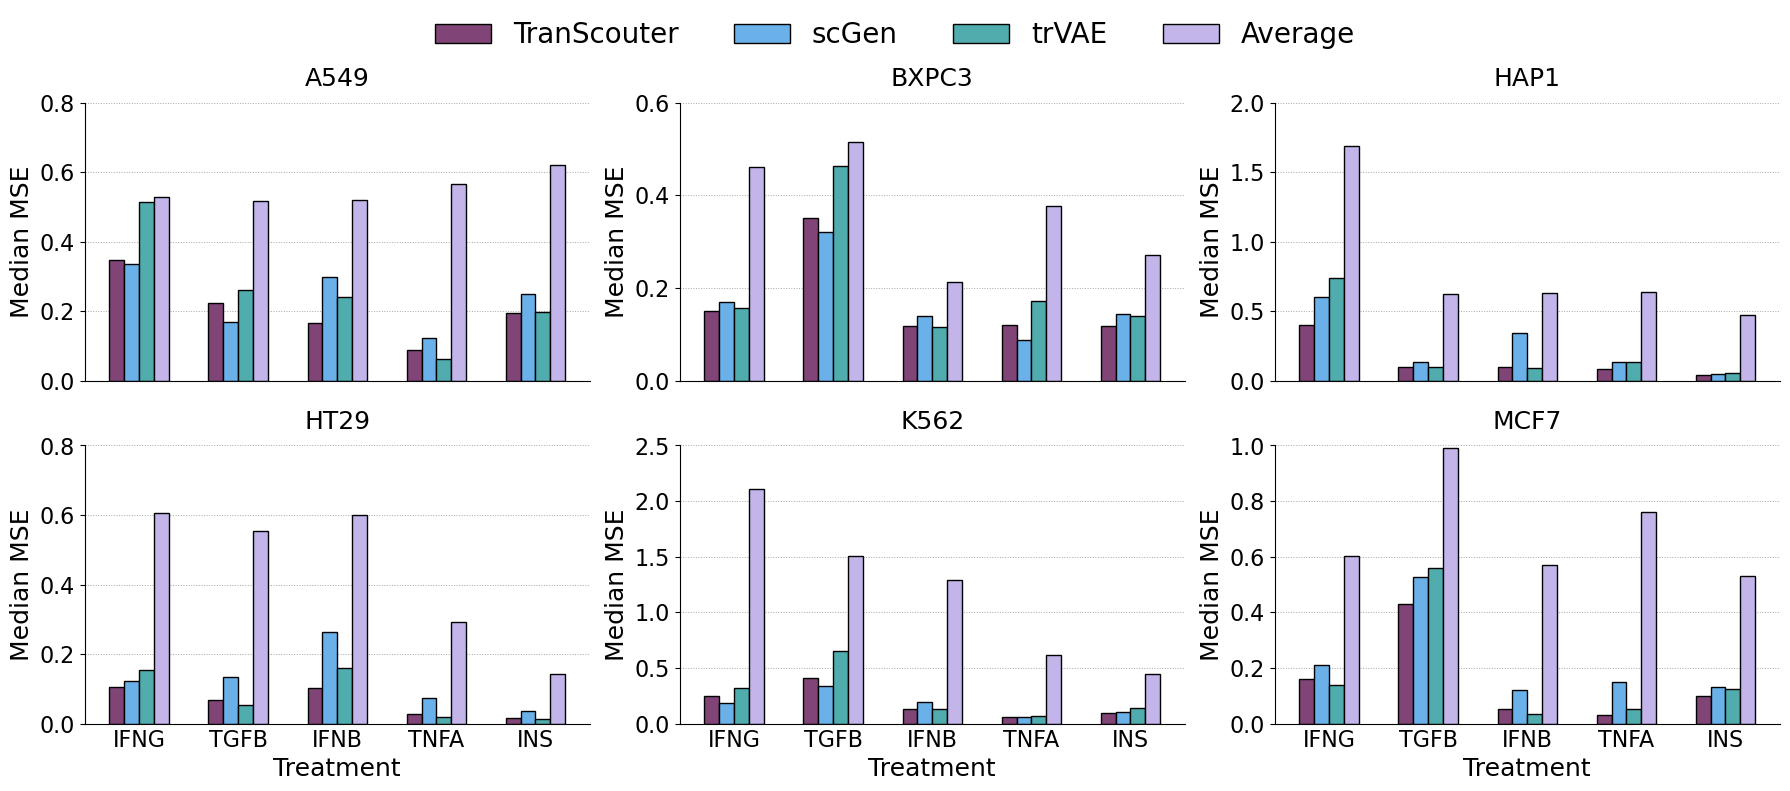

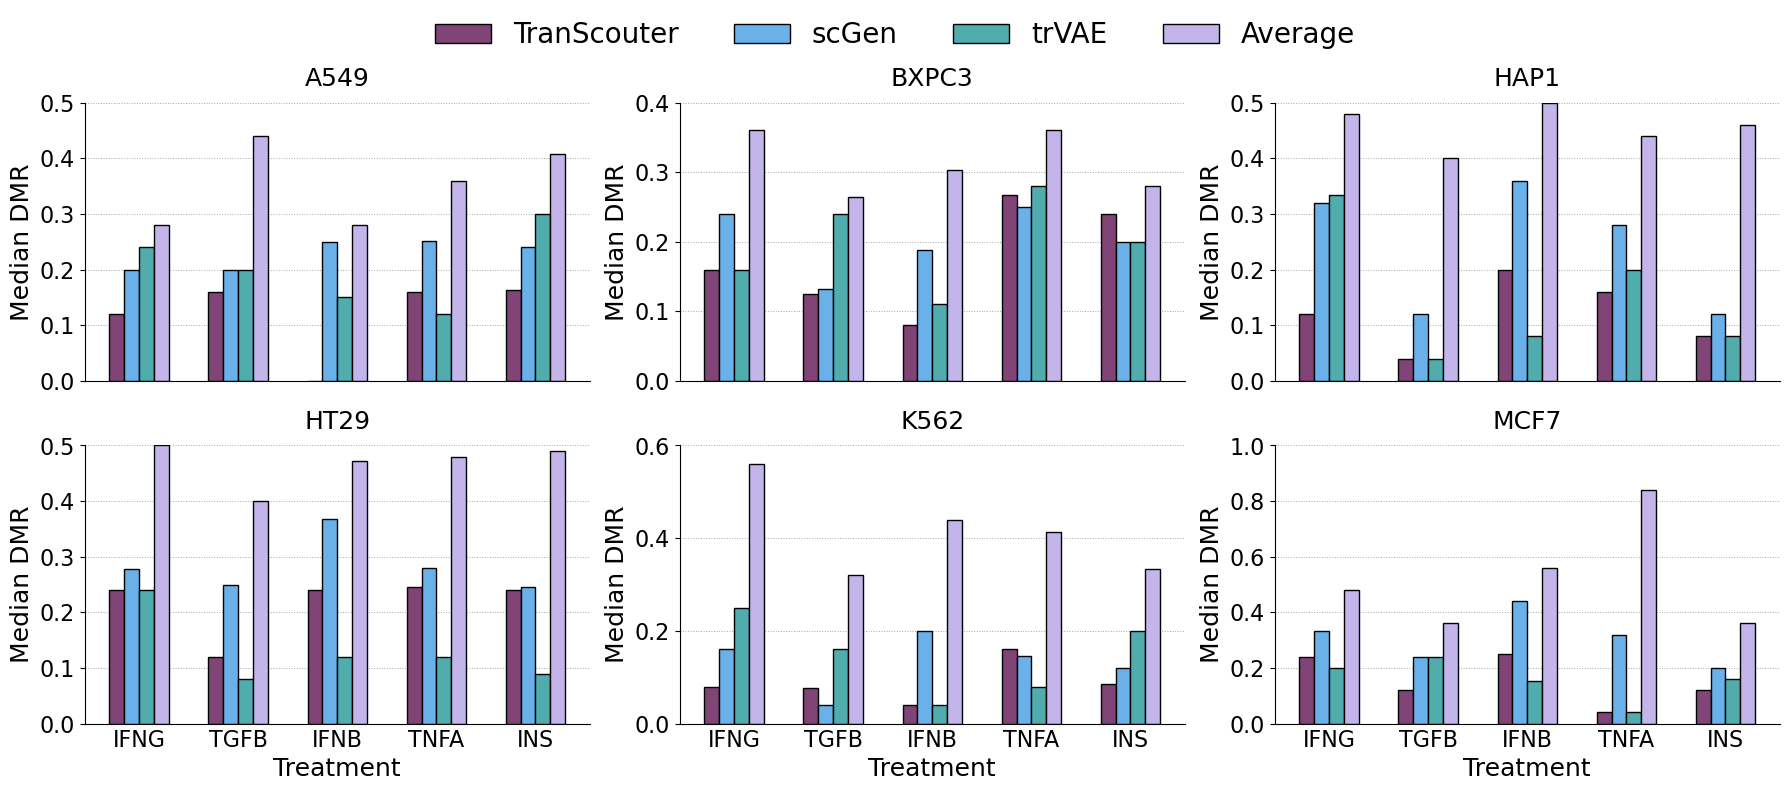

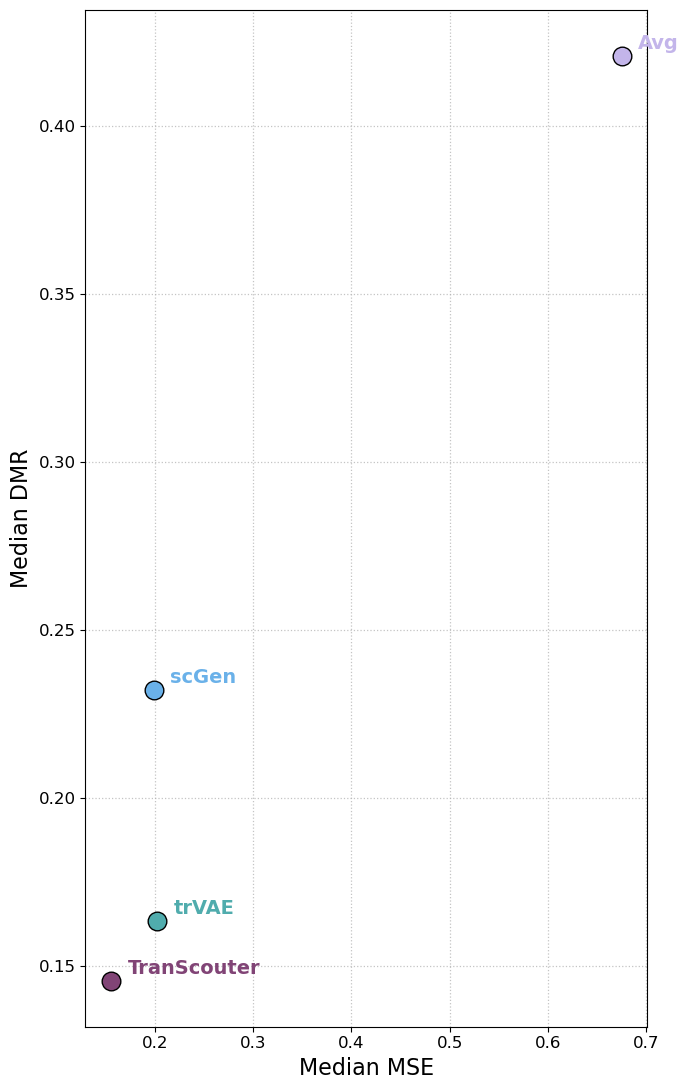

In [2]:
import pickle
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
with open("results/collected/jiang/seen_pred_results.pkl", "rb") as f:
    results = pickle.load(f)
with open("data/jiang/processed/top_degs_names.pkl", "rb") as f:
    top_degs_names = pickle.load(f)

method_colors = {
    "TranScouter": "#814476",
    "Avg":         "#c3b5ea",
    "scGen":       "#6ab1e9",
    "trVAE":       "#50acad",
    "Correlation": "#d9b77a",
    "CellOracle":  "#c98f8f",
}
method_cols   = ['TranScouter', 'scGen', 'trVAE', 'Avg']
display_names = ["TranScouter", "scGen", "trVAE", "Average"]
colors        = [method_colors[name] for name in method_cols]

true = results['True']
ctrl = results['Ctrl']
preds = {'TranScouter': results['TranScouter'],
         'Avg': results['Avg'],
         'scGen': results['scGen'],
         'trVAE': results['trVAE']}

metrics = {
    'MSE_degs': {name: {} for name in preds},
    'DMR_degs': {name: {} for name in preds}
}

for cov_pert in preds['TranScouter'].index:
    cov, pert = cov_pert.split('_')
    degs = top_degs_names[cov_pert]
    true_i = true.loc[cov_pert]
    ctrl_i = ctrl.loc[cov_pert.rsplit('_', 1)[0] + '_control']
    
    for name, df in preds.items():
        pred_i = df.loc[cov_pert]
        if len(degs) > 0:
            metrics['MSE_degs'][name][cov_pert] = mse(pred_i[degs], true_i[degs])
            metrics['DMR_degs'][name][cov_pert] = np.mean(np.sign(pred_i[degs] - ctrl_i[degs]) != np.sign(true_i[degs] - ctrl_i[degs]))

MSE_degs = pd.DataFrame(metrics['MSE_degs'])
DMR_degs = pd.DataFrame(metrics['DMR_degs'])

print("Median MSE on DEGs:")
print(MSE_degs.median())

print("\nMedian DMR on DEGs:")
print(DMR_degs.median())


def plot_celltype_panels(df, metric_name, save_prefix=None, ymin=0):
    df = df.assign(covariate=df.index.to_series().str.split('_', expand=True)[0])
    df[['celltype', 'treatment']] = df.covariate.str.split('+', expand=True)
    df['celltype'] = df['celltype'].str.upper()

    celltypes = df["celltype"].unique()
    treatments = df["treatment"].unique()
    
    agg = df.groupby(["celltype","treatment"], observed=False)[method_cols].median().reset_index()

    plt.rcParams.update({
        'axes.titlesize': 18,
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 16
    })
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
    axes = axes.ravel()

    for ax, ct in zip(axes, celltypes):
        sub = (agg[agg["celltype"] == ct]
                 .set_index("treatment")
                 .reindex(treatments))

        sub[method_cols].plot(
            kind="bar", ax=ax, color=colors,
            width=0.6, edgecolor='black', legend=False  # no subplot legend
        )

        yticks = ax.get_yticks()
        ymax = yticks[-2] if sub[method_cols].values.max() <= yticks[-2] else yticks[-1]
        
        # Set y-axis limits based on ymin parameter
        ymin_val = sub[method_cols].values.min() if ymin == 'adap' else ymin
        ax.set_ylim(ymin_val, ymax)
        ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='gray', alpha=0.7)
        ax.set_axisbelow(True)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        ax.set_title(f"{ct}", pad=12)
        ax.set_xlabel("Treatment")
        ax.set_ylabel(f"Median {metric_name}")
        ax.set_xticklabels(sub.index, rotation=0, ha="center")
        ax.tick_params(axis='x', length=0)

    for j in range(len(celltypes), len(axes)):
        axes[j].axis("off")

    # One global legend
    handles = [mpatches.Patch(facecolor=c, edgecolor="black") for c in colors]
    fig.legend(
        handles, display_names,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.0),  # moved down a bit
        ncol=len(display_names),
        fontsize=20,
        frameon=False
    )

    plt.tight_layout(rect=(0,0,1,0.93))  # shrink rect to lift plots closer to legend
    if globals().get("SAVE_FIGURES", False) and save_prefix:
        filename = f"{save_prefix}.png"
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Saved: {filename}")
    plt.show()


plot_celltype_panels(MSE_degs, "MSE",
                     save_prefix='figures/main/output/SeenPerturb_MSE')
plot_celltype_panels(DMR_degs, "DMR", ymin=0,
                     save_prefix='figures/main/output/SeenPerturb_DMR')


# Aggregate plot
mse_overall = MSE_degs.assign(covariate=MSE_degs.index.to_series().str.split('_', expand=True)[0]).groupby('covariate').median().mean()
dmr_overall = DMR_degs.assign(covariate=DMR_degs.index.to_series().str.split('_', expand=True)[0]).groupby('covariate').median().mean()
plt.figure(figsize=(7, 11))
for method in mse_overall.index:
    plt.scatter(
        mse_overall[method],
        dmr_overall[method],
        color=method_colors[method],
        s=180,
        edgecolor='black',
        zorder=3
    )
    plt.annotate(
        method,
        (mse_overall[method], dmr_overall[method]),
        textcoords="offset points",
        xytext=(12, 2),
        ha='left', va='bottom',
        fontsize=14, fontweight='bold',
        color=method_colors[method]
    )

plt.xlabel("Median MSE", fontsize=16)
plt.ylabel("Median DMR", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(linestyle=':', linewidth=0.9, alpha=0.75)
plt.tight_layout()
if globals().get("SAVE_FIGURES", False):
    plt.savefig('figures/main/output/SeenPerturb_aggregate.png', dpi=300, bbox_inches="tight")
plt.show()

## Example perturbation profile


TranScouter: 0 wrong-direction DEG(s)
  None
scGen: 10 wrong-direction DEG(s)
  DOCK2, LINC01583, RSAD2, FBXL21, GBP4, CD74, LINC01483, ETV7, SLC15A3, EPSTI1
trVAE: 5 wrong-direction DEG(s)
  LINC01583, FBXL21, GBP4, CD74, EPSTI1
Average: 7 wrong-direction DEG(s)
  SPOCK1, LINC01583, FBXL21, NCALD, EPSTI1, APH1A, RFPL1S


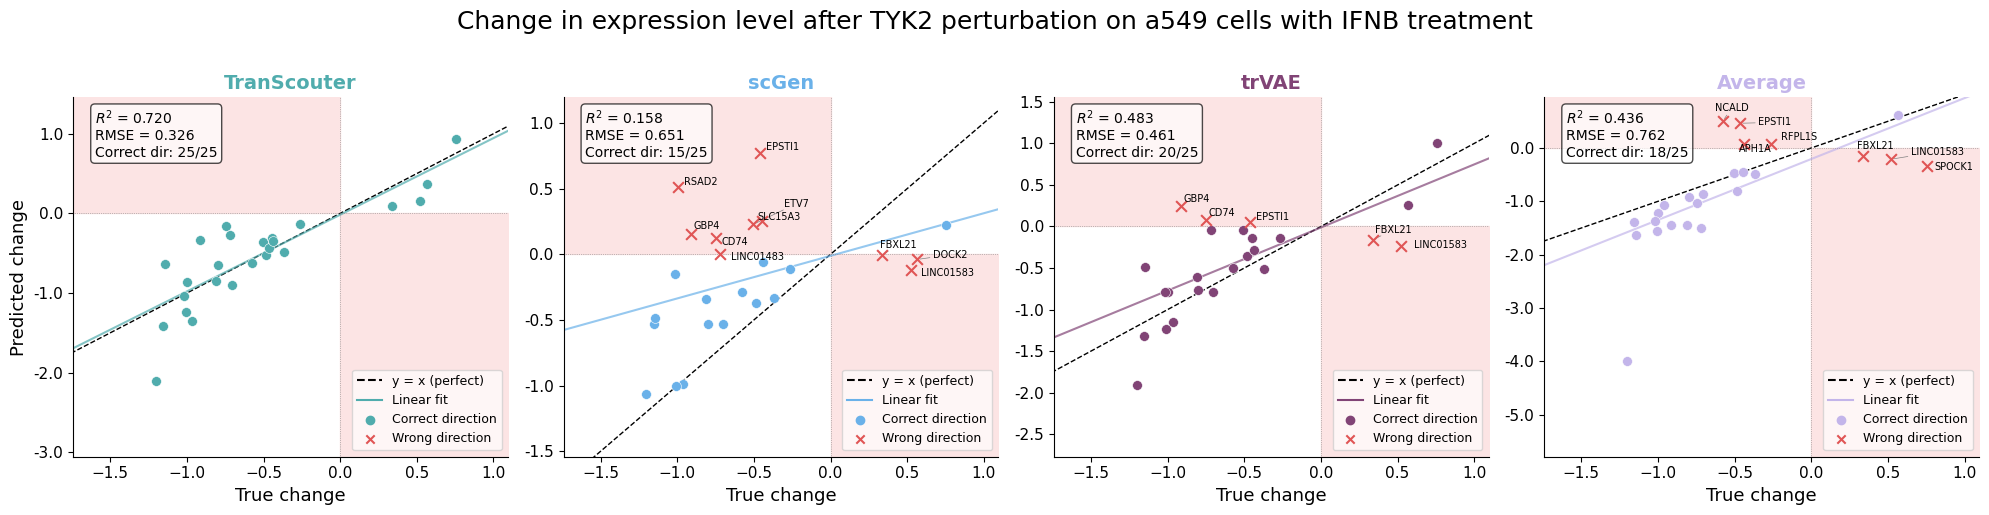

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
import os
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
with open("results/collected/jiang/seen_pred_results.pkl", "rb") as f:
    results = pickle.load(f)
with open("data/jiang/processed/top_degs_names.pkl", "rb") as f:
    top_degs_names = pickle.load(f)

cov_pert = 'a549+IFNB_TYK2'
cov, pert = cov_pert.split('_')
celltype, treatment = cov.split('+')
cov_ctrl = f'{cov}_control'
degs = top_degs_names[cov_pert]

ctrl = results['Ctrl'].loc[cov_ctrl, degs]
true = results['True'].loc[cov_pert, degs] - ctrl

methods = {
    'TranScouter': results['TranScouter'].loc[cov_pert, degs] - ctrl,
    'scGen': results['scGen'].loc[cov_pert, degs] - ctrl,
    'trVAE': results['trVAE'].loc[cov_pert, degs] - ctrl,
    'Average': results['Avg'].loc[cov_pert, degs] - ctrl,
}
colors = {
    'TranScouter': '#50acad',
    'scGen': '#6ab1e9',
    'trVAE': '#814476',
    'Average': '#c3b5ea',
}

plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
})

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    f"Change in expression level after {pert} perturbation on "
    f"{celltype} cells with {treatment} treatment",
    fontsize=18, y=1.02,
)

# x bounds: x_min (left) gives room for top-left stats box; x_max (right) for bottom-right legend
x_min = true.values.min() * 1.45
x_max = true.values.max() * 1.45

for ax, (method, pred) in zip(axes, methods.items()):
    color = colors[method]
    correct = np.sign(pred.values) == np.sign(true.values)

    # y_max (top) gives room for top-left stats box; y_min (bottom) for bottom-right legend
    y_min = pred.values.min() * 1.45
    y_max = pred.values.max() * 1.55
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # pink shading for wrong-direction quadrants
    ax.fill_between([x_min, 0], 0, y_max, color='#fce4e4', zorder=0)
    ax.fill_between([0, x_max], y_min, 0, color='#fce4e4', zorder=0)

    # y=x and linear fit
    diag_lim = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max))
    ax.plot([-diag_lim, diag_lim], [-diag_lim, diag_lim], 'k--', linewidth=1, zorder=1)
    lr = LinearRegression().fit(true.values.reshape(-1, 1), pred.values)
    x_fit = np.linspace(x_min, x_max, 100)
    ax.plot(x_fit, lr.predict(x_fit.reshape(-1, 1)), color=color, linewidth=1.5, alpha=0.7, zorder=2)

    # scatter
    ax.scatter(true[correct], pred[correct], color=color, marker='o', s=50, edgecolors='white', linewidths=0.4, zorder=3)
    ax.scatter(true[~correct], pred[~correct], color='#e05555', marker='x', s=60, linewidths=1.5, zorder=3)

    # gene labels for wrong predictions only, non-overlapping
    wrong_genes = np.array(degs)[~correct]
    wrong_gene_text = ", ".join(wrong_genes) if len(wrong_genes) else "None"
    print(f"{method}: {len(wrong_genes)} wrong-direction DEG(s)")
    print(f"  {wrong_gene_text}")
    
    texts = [ax.text(true[gene], pred[gene], gene, fontsize=7) for gene in wrong_genes]
    adjust_text(texts, ax=ax,
                x=true[wrong_genes].values, y=pred[wrong_genes].values,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # stats box — top-left; y_max and x_min are padded to keep this clear of data
    r2 = pearsonr(true.values, pred.values)[0] ** 2
    rmse = np.sqrt(mean_squared_error(true.values, pred.values))
    n_correct = correct.sum()
    ax.text(0.05, 0.97,
            f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nCorrect dir: {n_correct}/{len(degs)}",
            transform=ax.transAxes, fontsize=10, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.set_xlabel('True change')
    ax.set_ylabel('Predicted change' if ax == axes[0] else '')
    ax.set_title(method, color=color, fontweight='bold')

    handles = [
        plt.Line2D([0], [0], linestyle='--', color='black', label='y = x (perfect)'),
        plt.Line2D([0], [0], color=color, label='Linear fit'),
        plt.scatter([], [], color=color, marker='o', label='Correct direction'),
        plt.scatter([], [], color='#e05555', marker='x', label='Wrong direction'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=9, framealpha=0.7)
plt.tight_layout()
filename = f"figures/main/output/Examp_{pert}.png"
if globals().get("SAVE_FIGURES", False):
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename}")
plt.show()
